In [2]:
from brian2 import *
%matplotlib inline

In [3]:
tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

In [4]:
G = NeuronGroup(1, eqs, method='exact')
print('Before v = %s' % G.v[0])
M = StateMonitor(G, 'v', record=True)
run(50*ms)
print('After v = %s' % G.v[0])

Before v = 0.0
After v = 0.9932620530009143


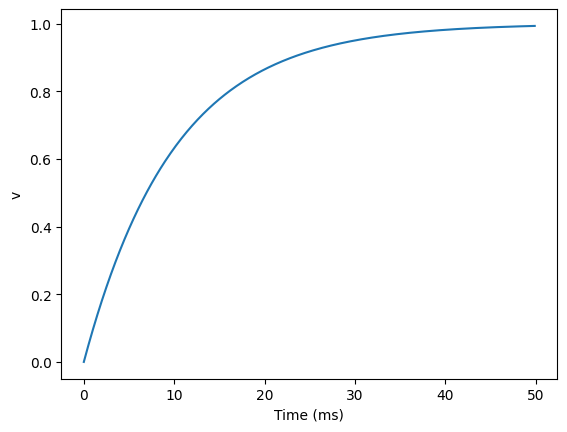

In [5]:
plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

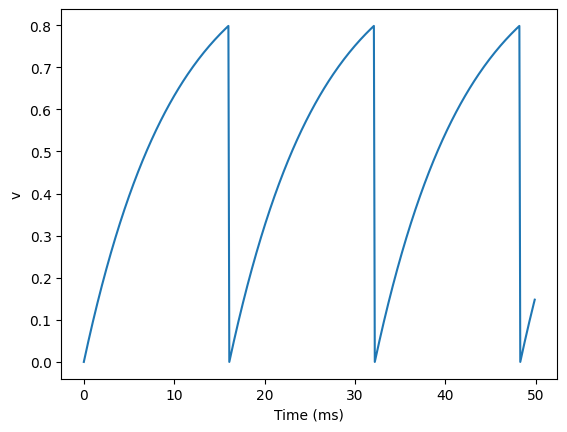

In [24]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', method='exact')
M = StateMonitor(G, 'v', record=0)

run(50*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

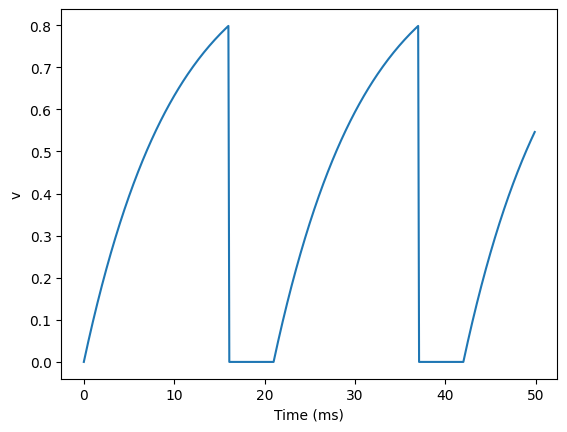

In [9]:
# To add refractory periods we alter the code in the ffg way:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1 (unless refractory) # Add "(unless refractory)"
'''

G = NeuronGroup(1, eqs, threshold='v>0.8', reset='v = 0', refractory=5*ms, method='exact') # Define refractory length in Neuron group definition
M = StateMonitor(G, 'v', record=0)

run(50*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v');

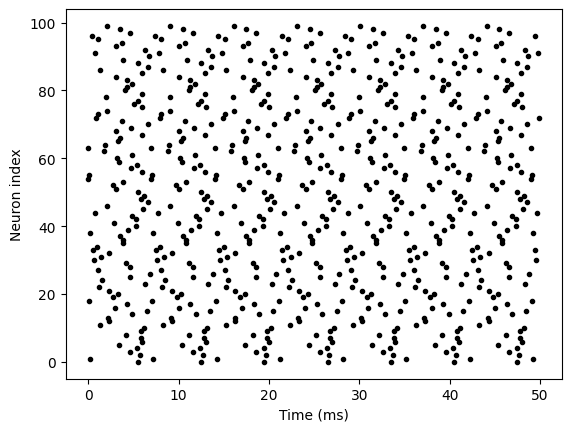

In [12]:
# We can simulate multiple Neurons in a group, we'll plot them differently to see what they're doing
start_scope()

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()' # Each Neuron will start with a different initial value of v to give some variety to when they each spike :)

spikemon = SpikeMonitor(G) # An object that holds info about when each spike happens and the index of each neuron that it happens to

run(50*ms)

plot(spikemon.t/ms, spikemon.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index');

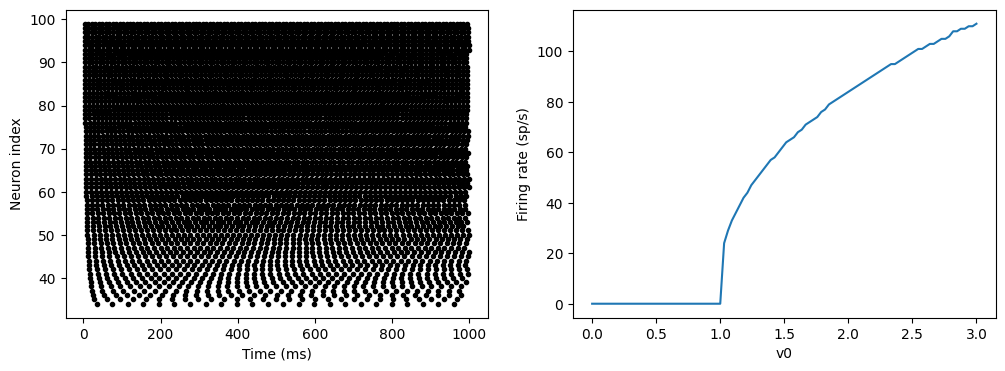

In [15]:
# Next we can make each Neuron do something cooler
# If each neuron has a different target to aim for, ie. instead of them each slowly drifiting to 1, they all drift to their own
# personal v0 value (depending on their index, the v0 will start low for lower indexes and be increased for neurons with a higher
# index).
# IMPORTANTLY: The threshold is now 1, which means... 
# If v0 < 1 -> it will never spike, since the assympote it reaches for, is below the threshold
# If v0 > 1 -> it will eventually cross the threshold and SPIKE!
# Since the bigger the value of v0, the faster the exponential curve increases the value of v per neuron and the more spikes we get!
# soooo we can say that:
# v0 acts like an input current strength!!!

start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms

eqs = '''
dv/dt = (v0-v)/tau : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', refractory=5*ms, method='exact')
M = SpikeMonitor(G)

G.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(M.t/ms, M.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(G.v0, M.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)');

# the first figure shows the spike raster (which neuron's spiked and how often). Note that the figure shows only > ~40 Neurons.
# this is because, lower neuron indexes don't show plots since they never spike, because their v0 was < 1
# the second figure shows the I-F curve (Input-frequency curve), the higher the input, the more frequently spikes occur

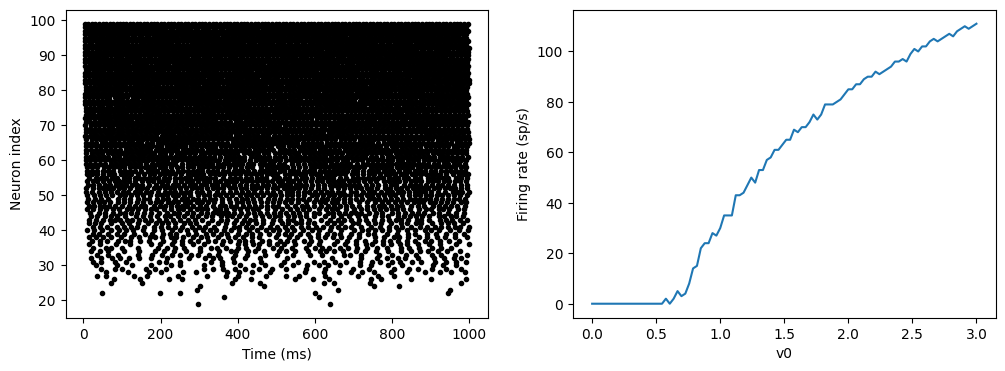

In [17]:
# The brain has inherent stochasticity in spike rates, so every neuron won't follow the exact differential equation for their input current
# To mimic this, we introduce the stochastic vairable xi into the DE which gives each neuron it's own independent stoachstic noise
# This makes the value of v jitter and jump for each neuron and may cause spikes earlier than expected, as in the brain's environemnt :)

start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms
sigma = 0.2

eqs = '''
dv/dt = (v0-v)/tau+sigma*xi*tau**-0.5 : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', refractory=5*ms, method='euler')
M = SpikeMonitor(G)

G.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(M.t/ms, M.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(G.v0, M.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)');

In [18]:
# EXERCISE TUTORIAL

Text(0, 0.5, 'Voltage(mV)')

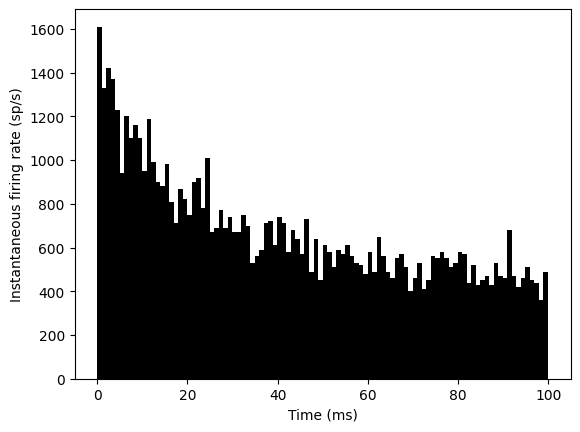

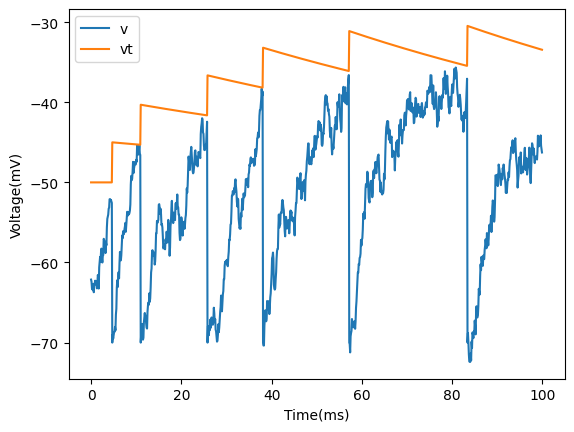

In [25]:
start_scope()

N = 1000
tau = 10*ms
vr = -70*mV
vt0 = -50*mV
delta_vt0 = 5*mV
tau_t = 100*ms
sigma = 0.5*(vt0-vr)
v_drive = 2*(vt0-vr)
duration = 100*ms

eqs = '''
dv/dt = (v_drive+vr-v)/tau + sigma*xi*tau**-0.5 : volt
dvt/dt = (vt0-vt)/tau_t : volt
'''

reset = '''
v = vr
vt += delta_vt0
'''

G = NeuronGroup(N, eqs, threshold='v>vt', reset=reset, refractory=5*ms, method='euler')
spikemon = SpikeMonitor(G)
M = StateMonitor(G, ['v', 'vt'], record=0)

G.v = 'rand()*(vt0-vr)+vr'
G.vt = vt0

run(duration)

_ = hist(spikemon.t/ms, 100, histtype='stepfilled', facecolor='k', weights=list(ones(len(spikemon))/(N*defaultclock.dt)))
xlabel('Time (ms)')
ylabel('Instantaneous firing rate (sp/s)');

figure()
plot(M.t/ms, M.v[0]/mV, label='v')
plot(M.t/ms, M.vt[0]/mV, label='vt')
legend()
xlabel('Time(ms)')
ylabel('Voltage(mV)')

## How to read the Differential Equations (Notes):
### $\frac{dv}{dt} = \frac{v_{target} - v}{\tau}$
* If $v$ is far from it's target $\to$ change fast
* If $v$ is close to target $\to$ change slow
* $\tau$ controls how slow or sluggish the process of v changing is

Most Neuron DE Models revole around:
* Exponential relaxation towards something
* Threshold condition
* Reset condition
* Possible noise

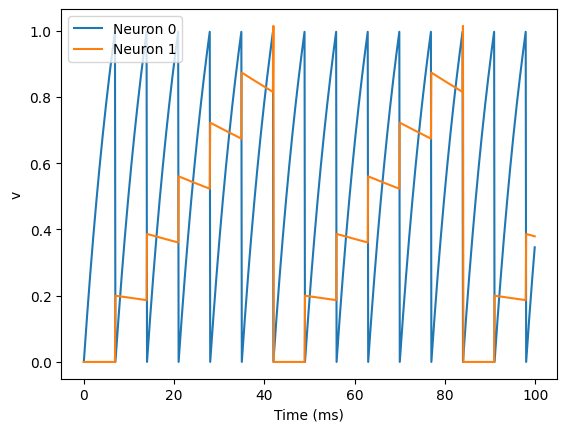

In [32]:
start_scope()

eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
tau : second
'''
G = NeuronGroup(2, eqs, threshold='v>1', reset='v = 0', method='exact')
G.I = [2, 0] # target value for N0 is 2, target value for N1 is 0 (and since it starts 0, it doesn't move on it's own towards the target)
G.tau = [10, 100]*ms # N0 has a pretty fast rate of reaching the target of 10ms, while N1 has a much slower rate of reaching the target

# Comment these two lines out to see what happens without Synapses
S = Synapses(G, G, on_pre='v_post += 0.2') # Here the weight of the synapse connection is hard coded to a value of 0.2
S.connect(i=0, j=1)

M = StateMonitor(G, 'v', record=True)

run(100*ms)

plot(M.t/ms, M.v[0], label='Neuron 0')
plot(M.t/ms, M.v[1], label='Neuron 1')
xlabel('Time (ms)')
ylabel('v')
legend();


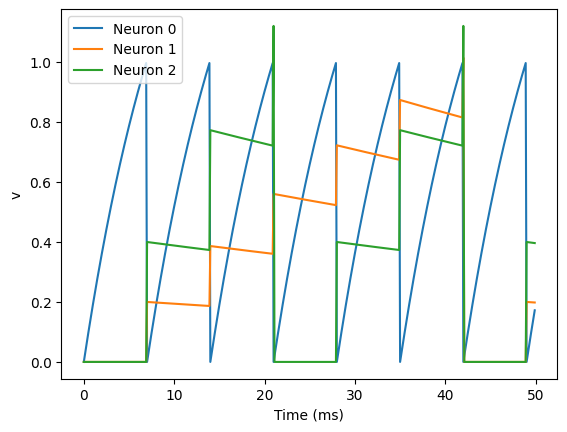

In [34]:
start_scope()

eqs = '''
dv/dt = (I-v)/tau : 1
I : 1
tau : second
'''
G = NeuronGroup(3, eqs, threshold='v>1', reset='v = 0', method='exact')
G.I = [2, 0, 0]
G.tau = [10, 100, 100]*ms

# Comment these two lines out to see what happens without Synapses
S = Synapses(G, G, 'w : 1', on_pre='v_post += w') # Here instead of adding a constant value to each synapse, each synapse now has their own
# indenpendent weight that can be controlled by a separate equation
S.connect(i=0, j=[1, 2]) # connects neuron 0 to neuron 1 and also connects neuron 0 to neuron 1
S.w = 'j*0.2' # j is the index of the postsynaptic neuron, so neuron "2" gets twice the kick that neuron "1" would from 0

# Since Neuron 0 has an input I of 2 and a tau of 10ms, it spikes
# Every spike from N0 triggers the on_pre for it's outgoing synapses
#     * Neuron 1 gets v += 0.2
#     * Neuron 2 gets v += 0.4
# Neuron 0 can therefore drive others with different strengths per connection! :D

M = StateMonitor(G, 'v', record=True)

run(50*ms)

plot(M.t/ms, M.v[0], label='Neuron 0')
plot(M.t/ms, M.v[1], label='Neuron 1')
plot(M.t/ms, M.v[2], label='Neuron 2')
xlabel('Time (ms)')
ylabel('v')
legend();

WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_2976/1664297910.py', line 6, in <module>
    S = Synapses(G, G) [brian2.core.base.unused_brian_object]
WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_2976/1664297910.py', line 5, in <module>
    G = NeuronGroup(N, 'v:1') [brian2.core.base.unused_brian_object]


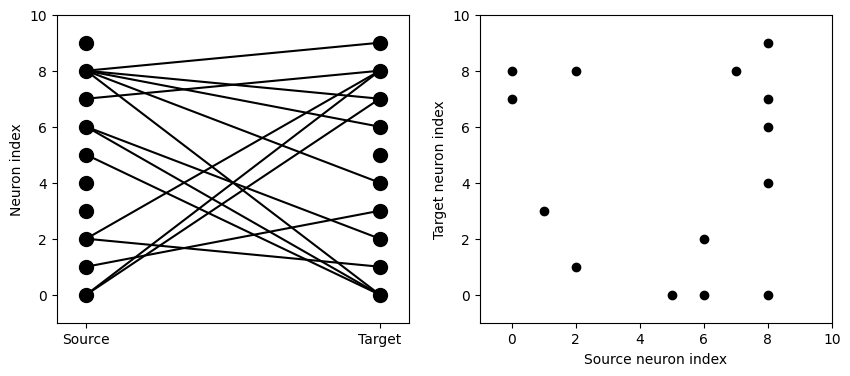

In [38]:
# Connectivity isn't usually hard coded
start_scope()

N = 10
G = NeuronGroup(N, 'v:1')
S = Synapses(G, G)
S.connect(condition='i!=j', p=0.2) # connect two neurons that don't have the same index with a probability of 0.2

def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 4))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10)
    plot(ones(Nt), arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')

visualise_connectivity(S)

## STDP learning rule (Spike-TIming Dependent Plasticity)
    "The change in synaptic weight depends on the timing differences between pre- and post-synaptic spikes"
Define:$\Delta t = t_{post} - t_{pre}$
* If $\Delta t > 0 \to$ pre fires first, post fires after (Good)
* If $\Delta t < 0 \to$ post fires first, pre fires after (Bad)

We define a function of the weight values over time, $W(\Delta t)$, as a piecewise function that describes the weight to be assigned depending on the value of $\Delta t$, increases in weight come from a positive $\Delta t$ and decreases in weight come from a negative $\Delta t$
The two cases of the piecewise function are defined as follows:

$W = A_{pre} e^{- \Delta t / \tau_{pre}}$ \
$W = A_{post} e^{\Delta t / \tau_{post}}$

For $+$ constant $A_{pre}$ and $-$ constant $A_{post} = - A_{pre} * 1.05$
The significance of the sign in the exponent for time indicates that for a weight increase, the value will decay exponentially as the value of $\Delta t$ gets larger
* If pre fires 1ms before post $\to$ strong strengthening
* If pre fires 40ms before post $\to$ tiny strengthening
And similarly for the weakining of the decrease weight case when $\Delta t < 0$

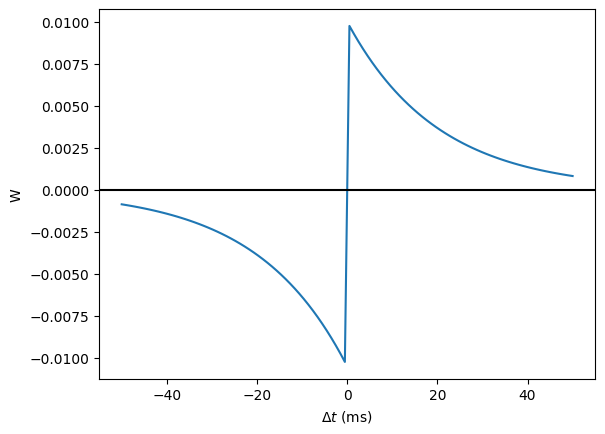

In [40]:
tau_pre = tau_post = 20*ms
A_pre = 0.01
A_post = -A_pre*1.05
delta_t = linspace(-50, 50, 100)*ms
W = where(delta_t>0, A_pre*exp(-delta_t/tau_pre), A_post*exp(delta_t/tau_post))
plot(delta_t/ms, W)
xlabel(r'$\Delta t$ (ms)')
ylabel('W')
axhline(0, ls='-', c='k');

Physically, storing the spike times for every single spike and computing all possible pair combinations between neurons would grow impossibly large, so we have a simpler solution

Each synapse keeps a set of two state variables:
* $a_{pre}$
* $a_{post}$ 

These variables are exponentially decaying traces of recent spiking activity. Their decay is modelled by the following differential equation: \
$\frac{d a_{pre}}{dt} = - \frac{a_{pre}}{\tau_{pre}}$ 

Who's solution follows exponential decay: \
$a_{pre}(t) = A_{pre}e^{-(t-t_{0}) / \tau_{pre}}$
(Which is of the same form as the exponential STDP curve above)

And similarly for $a_{post}$

NB. \
The variables $\tau_{pre}$ and $\tau_{post}$ are time constants of the learning traces that control the speed of the decay of the trace \
The variable $A_{pre}$ defines how much the pre trace jumps up on a pre spike (similarly for $A_{post}$)

In [41]:
start_scope()

taupre = taupost = 20*ms
wmax = 0.01
Apre = 0.01
Apost = -Apre*taupre/taupost*1.05

G = NeuronGroup(1, 'v:1', threshold='v>1', reset='')

S = Synapses(G, G,
             '''
             w : 1
             dapre/dt = -apre/taupre : 1 (event-driven)
             dapost/dt = -apost/taupost : 1 (event-driven)
             ''',
             on_pre='''
             v_post += w
             apre += Apre
             w = clip(w+apost, 0, wmax)
             ''',
             on_post='''
             apost += Apost
             w = clip(w+apre, 0, wmax)
             ''')

WARNING    The object 'synapses_1' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_2976/1664297910.py', line 6, in <module>
    S = Synapses(G, G) [brian2.core.base.unused_brian_object]
WARNING    The object 'neurongroup_2' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_2976/1664297910.py', line 5, in <module>
    G = NeuronGroup(N, 'v:1') [brian2.core.base.unused_brian_object]


#### Exact behavior of each synapse weight - $w$ depending on the value of $a_{pre}$ and $a_{post}$ defined by their respective differential equations

NB.
* on pre spike $a_{pre} \to$ jumps positive, then decays
* on post spike $a_{post} \to$ jumpts negative, then decays
* on pre spike $\to w$ += $a_{post}$
* on post spike $\to w$ += $a_{pre}$

$\tau_{pre} = \tau_{post} = 20ms$ \
$A_{pre} = 0.01$ \
$A_{post} = - A_{pre} * \frac{\tau_{pre}}{\tau_{post}*1.05}$

CASE 1: Pre fires shortly before Post (Should result in big increase in $w$) \
Pre fires:
* $a_{pre}$ += $A_{pre} \to a_{pre} = 0.01$
* $w$ += $a_{post}$ (since $a_{post} ≈ 0$, no real weight is added)
  
5 ms Pass (Calculate $a_{pre}$ when post spike occurs as: $a_{pre} ≈ 0.01 * e^{-5/20}$ which is much larger since 5ms is small relative to 20ms)

Post fires:
* $a_{post}$ += $A_{post}$ ($A_{post}$ becomes negative)
* $w$ += $a_{pre}$ ($w$ increases significantly!)


CASE 2: Pre fires long before Post (Should result in small increase in $w$) \
Pre fires:
* $a_{pre}$ += $A_{pre} \to a_{pre} = 0.01$
* $w$ += $a_{post}$ (since $a_{post} ≈ 0$, no real weight is added)
  
50 ms Pass (Calculate $a_{pre}$ when post spike occurs as: $a_{pre} ≈ 0.01 * e^{-50/20}$ which is much smaller since 50ms is large relative to 20ms)

Post fires:
* $a_{post}$ += $A_{post}$
* $w$ += $a_{pre}$ ($w$ increases very slightly!)


CASE 3: Pre fires shortly after Post (Should result in big decrease in $w$) \
Post fires:
* $a_{post}$ += $A_{post}$ ($a_{post}$ becomes negative)
* $w$ += $a_{pre}$ (roughly no change in w)

5 ms Pass (Calculate $a_{post}$ when pre spike occurs as: $a_{post} ≈ -0.0105 * e^{-5/20}$ which is strongly negative)

Pre fires:
* $a_{pre}$ += $A_{pre}$
* $w$ += $a_{post}$ ($w$ decreases significantly!)


CASE 4: Pre fires long after Post (Should result in small decrease in $w$) \
Post fires:
* $a_{post}$ += $A_{post}$ ($a_{post}$ becomes negative)
* $w$ += $a_{pre}$ (roughly no change in w)

50 ms Pass (Calculate $a_{post}$ when pre spike occurs as: $a_{post} ≈ -0.0105 * e^{-50/20}$ which is weakly negative, ie. close to 0)

Pre fires:
* $a_{pre}$ += $A_{pre}$
* $w$ += $a_{post}$ ($w$ decreases very slightly!)  

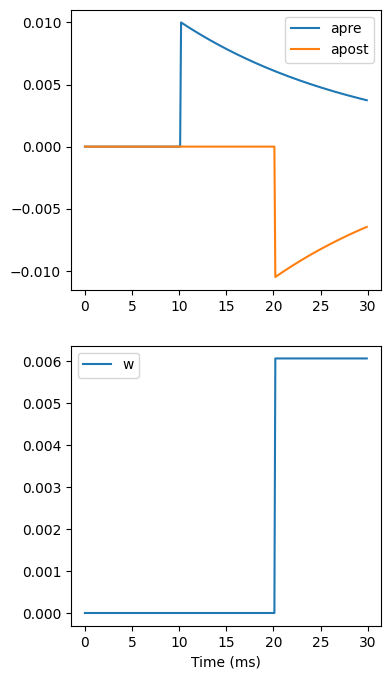

In [47]:
start_scope()

taupre = taupost = 20*ms
wmax = 0.01
Apre = 0.01
Apost = -Apre*taupre/taupost*1.05

G = NeuronGroup(2, 'v:1', threshold='t>(1+i)*10*ms', refractory=100*ms)

S = Synapses(G, G,
             '''
             w : 1
             dapre/dt = -apre/taupre : 1 (clock-driven)
             dapost/dt = -apost/taupost : 1 (clock-driven)
             ''',
             on_pre='''
             v_post += w
             apre += Apre
             w = clip(w+apost, 0, wmax)
             ''',
             on_post='''
             apost += Apost
             w = clip(w+apre, 0, wmax)
             ''', method='linear')
S.connect(i=0, j=1)
M = StateMonitor(S, ['w', 'apre', 'apost'], record=True)

run(30*ms)

figure(figsize=(4, 8))
subplot(211)
plot(M.t/ms, M.apre[0], label='apre')
plot(M.t/ms, M.apost[0], label='apost')
legend()
subplot(212)
plot(M.t/ms, M.w[0], label='w')
legend(loc='best')
xlabel('Time (ms)');

#### Now for a research question, setup and execution:

"Let’s start by looking at a very common task: doing multiple runs of a simulation with some parameter that changes. Let’s start off with something very simple, how does the firing rate of a leaky integrate-and-fire neuron driven by Poisson spiking neurons change depending on its membrane time constant? Let’s set that up."

What does that mean?
* The input to the input neuron(s) is driven randomly, calculated as a Poisson process (Poisson process has a defined average rate in Hz)
* We want to know how many times on average does the neuron emit a spike? That's the output firing rate (Dependent Variable)
* $\tau$ the membrane time constant controls how fast the membrane voltage leaks back toward rest and inegrates incoming input. We'll be varying $\tau$ to see it's impact on the firing rate of our LIF neuron

We will have to run the simulation multiple times (due to the noise from the Poisson input), measure the firing rate, plot it and read a conclusion :)

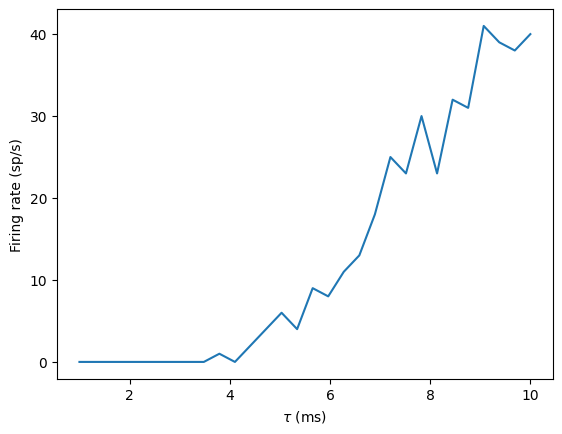

In [49]:
# remember, this is here for running separate simulations in the same notebook
start_scope()
# Parameters
num_inputs = 100
input_rate = 10*Hz
weight = 0.1
# Range of time constants
tau_range = linspace(1, 10, 30)*ms
# Use this list to store output rates
output_rates = []
# Iterate over range of time constants
for tau in tau_range:
    # Construct the network each time
    P = PoissonGroup(num_inputs, rates=input_rate)
    eqs = '''
    dv/dt = -v/tau : 1
    '''
    G = NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')
    S = Synapses(P, G, on_pre='v += weight')
    S.connect()
    M = SpikeMonitor(G)
    # Run it and store the output firing rate in the list
    run(1*second)
    output_rates.append(M.num_spikes/second)
# And plot it
plot(tau_range/ms, output_rates)
xlabel(r'$\tau$ (ms)')
ylabel('Firing rate (sp/s)');

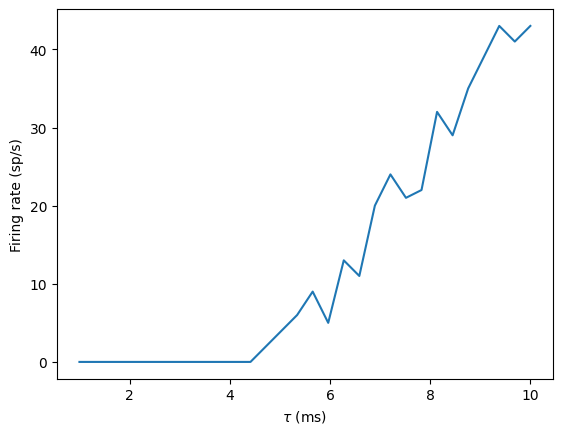

In [50]:
# That's slow to run since every loop regenerates the entire network, 
# but Brian2 has a function to just reset the network to it's original
# state, so we just generate the network once and keep resetting it

start_scope()
num_inputs = 100
input_rate = 10*Hz
weight = 0.1
tau_range = linspace(1, 10, 30)*ms
output_rates = []
# Construct the network just once
P = PoissonGroup(num_inputs, rates=input_rate)
eqs = '''
dv/dt = -v/tau : 1
'''
G = NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')
S = Synapses(P, G, on_pre='v += weight')
S.connect()
M = SpikeMonitor(G)
# Store the current state of the network
store()
for tau in tau_range:
    # Restore the original state of the network
    restore()
    # Run it with the new value of tau
    run(1*second)
    output_rates.append(M.num_spikes/second)
plot(tau_range/ms, output_rates)
xlabel(r'$\tau$ (ms)')
ylabel('Firing rate (sp/s)');